## CAPM Model

In [110]:
# !pip install pandas_ta
# !pip install --upgrade numpy pandas_ta

In [1]:
from statsmodels.regression.rolling import RollingOLS
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
import pandas_ta
import warnings
warnings.filterwarnings('ignore')

## Data Processing

In [44]:
sp500 = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]

sp500['Symbol'] = sp500['Symbol'].str.replace('.', '-')

symbols_list = sp500['Symbol'].unique().tolist()
symbols_list.append('^GSPC')
# start_date = '2024-04-01'
end_date = '2024-12-31'

start_date = pd.to_datetime(end_date)-pd.DateOffset(365*5)

df = yf.download(tickers=symbols_list,
                 start=start_date,
                 end=end_date,auto_adjust =False).stack()

df.index.names = ['date', 'ticker']

df.columns = df.columns.str.lower()
df.head()

[*********************100%***********************]  504 of 504 completed


Price              adj close      close       high        low       open  \
date       ticker                                                          
2020-01-02 A       82.885239  85.949997  86.349998  85.199997  85.900002   
           AAPL    72.716072  75.087502  75.150002  73.797501  74.059998   
           ABBV    71.589775  89.550003  89.570000  88.510002  89.080002   
           ABT     79.273941  86.949997  86.959999  85.800003  86.059998   
           ACGL    41.268997  43.400002  43.400002  42.880001  43.009998   

Price                   volume  
date       ticker               
2020-01-02 A         1410500.0  
           AAPL    135480400.0  
           ABBV      5639200.0  
           ABT       4969000.0  
           ACGL      1376700.0

In [45]:
# Risk-free rate (10-year U.S. Treasury yield as a percentage, e.g., 4.305%)
risk_free_rate = 0.04035/252  # Convert annual rate to daily rate
risk_free_rate

0.0001601190476190476

In [46]:
df2 = df.reset_index()[['date', 'ticker', 'close']]
df2.head()
df2 = df2[(df2['ticker'] == 'NVDA') | (df2['ticker'] == '^GSPC') ]
df2.head()

Price,date,ticker,close
336,2020-01-02,NVDA,5.997750
490,2020-01-02,^GSPC,3257.850098
827,2020-01-03,NVDA,5.901750
981,2020-01-03,^GSPC,3234.850098
1318,2020-01-06,NVDA,5.926500


In [47]:
Stock_close = df2.pivot(index = 'date', columns = 'ticker',values = 'close')
Stock_close = Stock_close.pct_change().dropna()
Stock_close = Stock_close.rename(columns={'^GSPC': 'GSPC'})
Stock_close = Stock_close.reset_index()
Stock_close_capm = Stock_close
Stock_close.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1256 entries, 0 to 1255
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    1256 non-null   datetime64[ns]
 1   NVDA    1256 non-null   float64       
 2   GSPC    1256 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 29.6 KB


In [48]:
Stock_close_capm['exs_rtn_nvda'] = Stock_close_capm['NVDA'] -risk_free_rate

Stock_close_capm['MKT_prm'] = Stock_close_capm['GSPC'] -risk_free_rate
Stock_close_capm = Stock_close_capm[['date','exs_rtn_nvda','MKT_prm']]
Stock_close_capm.head()



ticker,date,exs_rtn_nvda,MKT_prm
0,2020-01-03,-0.016166,-0.007220
1,2020-01-06,0.004034,0.003373
2,2020-01-07,0.011947,-0.002963
3,2020-01-08,0.001715,0.004742
4,2020-01-09,0.010822,0.006495


In [49]:

Stock_close_capm = Stock_close_capm.set_index('date')
Stock_close_capm.info()
Stock_close_capm.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1256 entries, 2020-01-03 to 2024-12-30
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   exs_rtn_nvda  1256 non-null   float64
 1   MKT_prm       1256 non-null   float64
dtypes: float64(2)
memory usage: 29.4 KB


ticker,exs_rtn_nvda,MKT_prm
date,,
2020-01-03,-0.016166,-0.007220
2020-01-06,0.004034,0.003373
2020-01-07,0.011947,-0.002963
2020-01-08,0.001715,0.004742
2020-01-09,0.010822,0.006495


## Plotting the scatter plot over the years

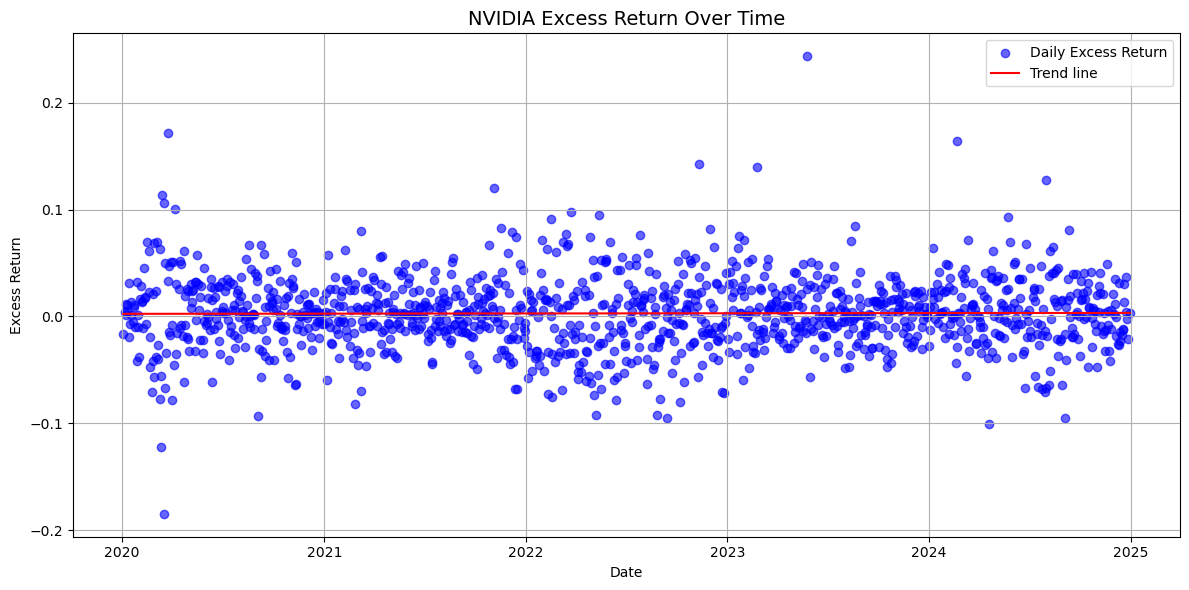

In [50]:
import matplotlib.pyplot as plt

# Use the index as date (already sorted)
dates = Stock_close_capm.index
returns = Stock_close_capm['exs_rtn_nvda']

# Plot scatter
plt.figure(figsize=(12, 6))
plt.scatter(dates, returns, color='blue', alpha=0.6, label="Daily Excess Return")

# Optionally: add trend line using polyfit (convert dates to numbers)
import matplotlib.dates as mdates
date_nums = mdates.date2num(dates)
m, c = np.polyfit(date_nums, returns, 1)
plt.plot(dates, m * date_nums + c, color='red', label=f'Trend line')

# Title and labels
plt.title('NVIDIA Excess Return Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Excess Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Scatter plot against the market return

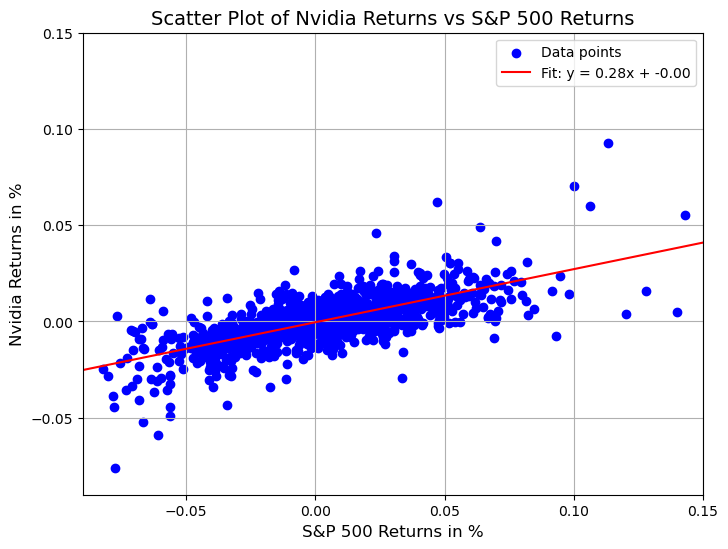

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Fit a line: y = mx + c
m, c = np.polyfit(Stock_close_capm['exs_rtn_nvda'], Stock_close_capm['MKT_prm'], 1)

# Plot scatter
plt.figure(figsize=(8, 6))
plt.scatter(Stock_close_capm['exs_rtn_nvda'], Stock_close_capm['MKT_prm'], color='blue', alpha=1, label="Data points")

# Plot fitted line
x_vals = np.array(plt.gca().get_xlim())  # Get x limits from the plot
y_vals = m * x_vals + c
plt.plot(x_vals, y_vals, color='red', label=f'Fit: y = {m:.2f}x + {c:.2f}')

# Titles and labels
plt.title('Scatter Plot of Nvidia Returns vs S&P 500 Returns', fontsize=14)
plt.xlim(-0.09,0.15)
plt.ylim(-0.09,0.15)
plt.xlabel('S&P 500 Returns in %', fontsize=12)
plt.ylabel('Nvidia Returns in %', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

## - Distribution OF NVIDIA return over the year -

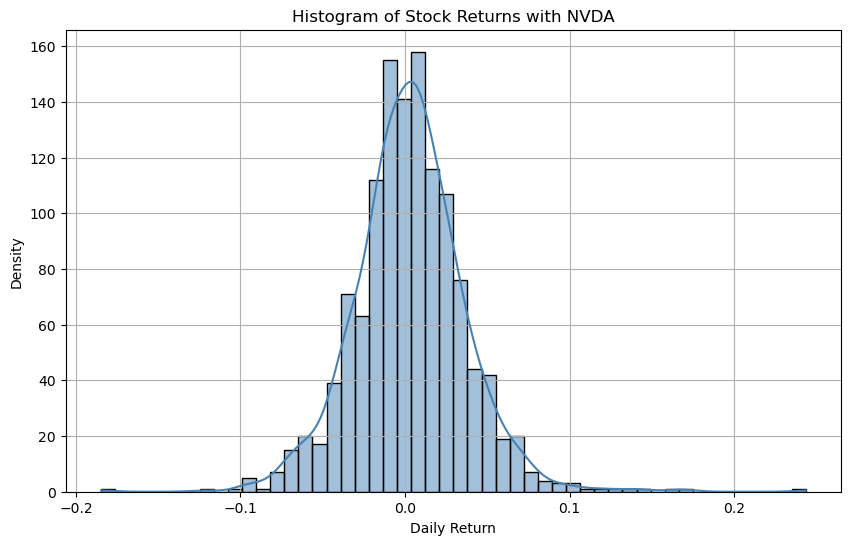

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop missing values if any


plt.figure(figsize=(10, 6))
sns.histplot(Stock_close_capm['exs_rtn_nvda'], bins=50, kde=True, color='steelblue')
plt.title('Histogram of Stock Returns with NVDA')
plt.xlabel('Daily Return')
plt.ylabel('Density')
plt.grid(True)
plt.show()

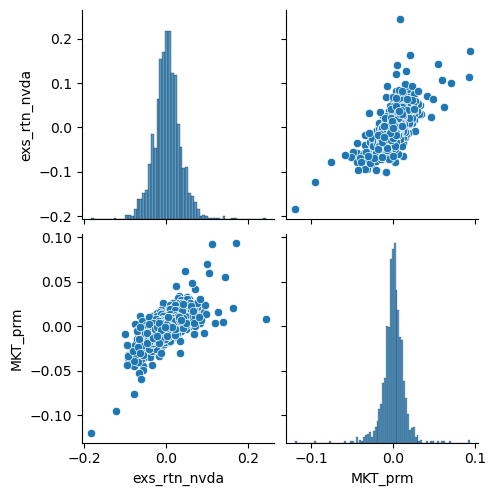

In [57]:
pairplot = sns.pairplot(Stock_close_capm)
pairplot

# 1. Regression model

In [58]:
import statsmodels.formula.api as smf
import pandas as pd


# # Fit the regression model
reg_nvda = smf.ols('exs_rtn_nvda ~ MKT_prm', data=Stock_close_capm).fit()


# # Print the summary
print(reg_nvda.summary())

                            OLS Regression Results                            
Dep. Variable:           exs_rtn_nvda   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                     1179.
Date:                Tue, 15 Apr 2025   Prob (F-statistic):          9.70e-183
Time:                        01:04:11   Log-Likelihood:                 2883.7
No. Observations:                1256   AIC:                            -5763.
Df Residuals:                    1254   BIC:                            -5753.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0022      0.001      3.191      0.0

In [59]:
# Extract alpha (intercept) and beta (coefficient of MKT_prm)
alpha = reg_nvda.params['Intercept']
beta = reg_nvda.params['MKT_prm']
r_squared_capm = reg_nvda.rsquared
adj_r_squared_capm = reg_nvda.rsquared_adj

# Print alpha and beta
print(f"Alpha (α): {alpha}")
print(f"Beta (β): {beta}")
print(f"R-squared: {r_squared_capm}")
print(f"Adjusted R-squared: {adj_r_squared_capm}")
# Example: Use CAPM equation to compute expected return
# Expected return = α + β * market_premium
# You can replace `market_premium_value` with an actual value

# market_premium_value = (1+Stock_close_capm['MKT_prm'].mean())**252-1  # Example market premium (6%)
# expected_return = alpha + beta * market_premium_value

# print(f"Expected Return: {expected_return*100:.4f}")

Alpha (α): 0.002196313850607828
Beta (β): 1.757371587219926
R-squared: 0.4846706257969544
Adjusted R-squared: 0.4842596773326776


##  Bias-Variance Tradeoff

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Create polynomial features (degrees 2 and 3)
poly = PolynomialFeatures(degree=2)  # Change to degree=3 for cubic terms
X_poly = poly.fit_transform(Stock_close_capm[['MKT_prm']])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_poly, Stock_close_capm['exs_rtn_nvda'], test_size=0.2, random_state=42)

# Fit the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate performance (use RMSE, R-squared, etc.)
from sklearn.metrics import mean_squared_error
import numpy as np

# RMSE calculation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE for Polynomial Regression (Degree 2): {rmse}")

from sklearn.model_selection import cross_val_score

# Cross-validation for degree 2 polynomial
cv_scores = cross_val_score(model, X_poly, Stock_close_capm['exs_rtn_nvda'], cv=5, scoring='neg_mean_squared_error')
mean_cv_score = np.mean(cv_scores)
print(f"Mean CV Error (Degree 2 Polynomial): {mean_cv_score}")

# You can repeat the same for degree 3 polynomial by changing the degree in PolynomialFeatures



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Prepare your data
X = Stock_close_capm[['MKT_prm']]  # Independent variable
y = Stock_close_capm['exs_rtn_nvda']  # Dependent variable

# Set the maximum polynomial degree
max_degree = 10

# Initialize lists to store cross-validation results
train_errors = []
val_errors = []

# Loop through degrees 1 to max_degree to fit polynomial models
for degree in range(1, max_degree+1):
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)  # Create polynomial features

    # Fit linear regression model
    model = LinearRegression()

    # Cross-validation for training error (use neg_mean_squared_error for MSE)
    mse_train = cross_val_score(model, X_poly, y, cv=5, scoring='neg_mean_squared_error')
    train_errors.append(-np.mean(mse_train))  # Negative MSE as it's returned by sklearn

    # Calculate validation error
    X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    val_errors.append(mean_squared_error(y_test, y_pred))  # MSE on validation set

# Plot the error curves
plt.figure(figsize=(10,6))
plt.plot(range(1, max_degree+1), train_errors, label='Train Error', marker='o')
plt.plot(range(1, max_degree+1), val_errors, label='Validation Error', marker='o')
plt.title('Bias-Variance Tradeoff')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

# Find the degree with the lowest validation error
best_degree = np.argmin(val_errors) + 1
print(f"The best polynomial degree is: {best_degree}")



## Now to check how this model works on new data lets split the data into training and test

# Split the data in Training and test 

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Prepare the data
X = Stock_close_capm[['MKT_prm']]  # Independent variable
y = Stock_close_capm['exs_rtn_nvda']  # Dependent variable

# Sort data by date to ensure chronological order (if not already sorted)
Stock_close_capm = Stock_close_capm.sort_index()

# Split the data (e.g., 80% for training, 20% for testing based on time)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [19]:
# Initialize the linear regression model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Calculate Adjusted R-squared
n = len(y_test)  # number of observations
p = X_train.shape[1]  # number of predictors
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Print results
print(f'Mean Squared Error (MSE): {mse}')
print(f'R-squared (R2): {r2}')
print(f'Adjusted R-squared: {adj_r2}')

Mean Squared Error (MSE): 0.0007006080570298478
R-squared (R2): 0.3552021980915331
Adjusted R-squared: 0.35262300688389914


# Model Performance on Test Data
 - Mean Squared Error (MSE): 0.00070

- This indicates that the model's predictions deviate from the actual excess returns by a small average squared error. However, in financial data, even small errors can be meaningful depending on the context and scale of returns.

- R-squared (R²): 0.355

- About 35.5% of the variation in NVIDIA’s excess returns is explained by the market risk premium (MKT_prm). This shows a moderate level of explanatory power, but a large portion (around 64.5%) of the variance is still unexplained, which might be due to other risk factors not captured in the CAPM model.

- Adjusted R-squared: 0.353

- This is very close to the R², indicating that the model's simplicity (with just one predictor) doesn't suffer from overfitting due to unnecessary features.


## 2.  XGBoost

In [53]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

xgb_capm = XGBRegressor(objective='reg:squarederror', random_state=42, n_estimators=100)
xgb_capm.fit(X_train, y_train)

# Step 4: Predict + Evaluate
y_pred = xgb_capm.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
n, p = X_test.shape
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Step 5: Output results
print("XGBoost CAPM Performance:")
print(f"MSE: {mse}")
print(f"R²: {r2}")
print(f"Adjusted R²: {adj_r2}")

XGBoost CAPM Performance:
MSE: 0.0007283202891885002
R²: 0.3296975151199598
Adjusted R²: 0.32701630518043967


## Running model on train and test data set

In [64]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Step 1: CAPM XGBoost
xgb_capm = XGBRegressor(objective='reg:squarederror', random_state=42, n_estimators=100)
xgb_capm.fit(X_train, y_train)
y_pred_xgb = xgb_capm.predict(X_test)

# Evaluate XGBoost
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
adj_r2_xgb = 1 - (1 - r2_xgb) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

print("\n XGBoost CAPM Performance:")
print(f"MSE: {mse_xgb}")
print(f"R²: {r2_xgb}")
print(f"Adjusted R²: {adj_r2_xgb}")

# Step 2: CAPM Linear Regression (OLS)
reg_capm = smf.ols('exs_rtn_nvda ~ MKT_prm', data=Stock_close_capm.iloc[:train_size]).fit()
X_test_sm = sm.add_constant(X_test)
y_pred_ols = reg_capm.predict(X_test_sm)

# Evaluate OLS
mse_ols = mean_squared_error(y_test, y_pred_ols)
r2_ols = r2_score(y_test, y_pred_ols)
adj_r2_ols = 1 - (1 - r2_ols) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

print("\n CAPM Linear Regression on Test Data:")
print(f"MSE: {mse_ols}")
print(f"R²: {r2_ols}")
print(f"Adjusted R²: {adj_r2_ols}")



 XGBoost CAPM Performance:
MSE: 0.0007283202891885002
R²: 0.3296975151199598
Adjusted R²: 0.32701630518043967

 CAPM Linear Regression on Test Data:
MSE: 0.0007006080570298482
R²: 0.35520219809153275
Adjusted R²: 0.3526230068838988


# XGBoost (tuned)

In [71]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

# Define base model
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

# Define search grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit on training data
grid_search.fit(X_train, y_train)

# Best model
best_xgb = grid_search.best_estimator_

# Predict on test set
y_pred = best_xgb.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
n, p = X_test.shape
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
rmse = mse ** 0.5

print("\n📊 Tuned XGBoost CAPM Performance:")
print(f"Best params: {grid_search.best_params_}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")
print(f"Adjusted R²: {adj_r2}")


Fitting 5 folds for each of 72 candidates, totalling 360 fits

📊 Tuned XGBoost CAPM Performance:
Best params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50, 'subsample': 0.8}
MSE: 0.0006739518383869574
RMSE: 0.025960582396913928
R²: 0.37973498930862715
Adjusted R²: 0.37725392926586165


## Creating the copy of data and adding more features to improve the model

In [72]:
df = Stock_close_capm.copy()

# Create new features
df['MKT_prm_squared'] = df['MKT_prm'] ** 2
df['MKT_prm_lag1'] = df['MKT_prm'].shift(1)
df['VOLATILITY_5d'] = df['MKT_prm'].rolling(window=5).std()
df['MOMENTUM_10d'] = df['MKT_prm'].pct_change(periods=10)

# Drop NaN rows from rolling and lag
df = df.dropna()

# Define features and target
X = df[['MKT_prm', 'MKT_prm_squared', 'MKT_prm_lag1', 'VOLATILITY_5d', 'MOMENTUM_10d']]
y = df['exs_rtn_nvda']

# Lag features
df['MKT_prm_lag1'] = df['MKT_prm'].shift(1)
df['MKT_prm_lag2'] = df['MKT_prm'].shift(2)
df['MKT_prm_lag3'] = df['MKT_prm'].shift(3)
df['exs_rtn_nvda_lag1'] = df['exs_rtn_nvda'].shift(1)
df['exs_rtn_nvda_lag5'] = df['exs_rtn_nvda'].shift(5)

# Rolling stats on MKT_prm
df['rolling_mean_5d'] = df['MKT_prm'].rolling(window=5).mean()
df['rolling_std_5d'] = df['MKT_prm'].rolling(window=5).std()

# Rolling stats on exs_rtn_nvda
df['rolling_mean_nvda_5d'] = df['exs_rtn_nvda'].rolling(window=5).mean()
df['rolling_std_nvda_5d'] = df['exs_rtn_nvda'].rolling(window=5).std()

# Nonlinear term
df['MKT_prm_squared'] = df['MKT_prm'] ** 2

# Drop rows with NaNs from rolling/lags
df = df.dropna()

# Final feature list
X = df[[
    'MKT_prm',
    'MKT_prm_squared',
    'MKT_prm_lag1',
    'MKT_prm_lag2',
    'MKT_prm_lag3',
    'exs_rtn_nvda_lag1',
    'exs_rtn_nvda_lag5',
    'rolling_mean_5d',
    'rolling_std_5d',
    'rolling_mean_nvda_5d',
    'rolling_std_nvda_5d'
]]

y = df['exs_rtn_nvda']


In [97]:
df.head()

ticker,exs_rtn_nvda,MKT_prm,MKT_prm_squared,MKT_prm_lag1,VOLATILITY_5d,MOMENTUM_10d,MKT_prm_lag2,MKT_prm_lag3,exs_rtn_nvda_lag1,exs_rtn_nvda_lag5,rolling_mean_5d,rolling_std_5d,rolling_mean_nvda_5d,rolling_std_nvda_5d
date,,,,,,,,,,,,,,
2020-01-27,-0.041201,-0.015891,0.000253,-0.009202,0.007115,4.270070,0.000981,0.000129,-0.009572,0.001246,-0.005359,0.007115,-0.007376,0.020851
2020-01-28,0.032188,0.009893,0.000098,-0.015891,0.009954,0.451486,-0.009202,0.000981,-0.041201,-0.005536,-0.002818,0.009954,0.000168,0.027461
2020-01-29,-0.009960,-0.001027,0.000001,0.009893,0.009882,-0.386742,-0.015891,-0.009202,0.032188,0.008592,-0.003049,0.009882,-0.003542,0.027291
2020-01-30,0.000939,0.002974,0.000009,-0.001027,0.010122,0.739242,0.009893,-0.015891,-0.009960,0.010835,-0.002650,0.010122,-0.005521,0.026329
2020-01-31,-0.038320,-0.017866,0.000319,0.002974,0.012077,-3.177065,-0.001027,0.009893,0.000939,-0.009572,-0.004383,0.012077,-0.011271,0.030278


# Data Split

In [93]:
split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]


In [98]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
grid = GridSearchCV(xgb, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5, verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)

best_xgb = grid.best_estimator_


Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [99]:
y_pred = best_xgb.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
n, p = X_test.shape
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("\n📊 Tuned XGBoost with Engineered CAPM Features:")
print(f"Best Params: {grid.best_params_}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")
print(f"Adjusted R²: {adj_r2}")



📊 Tuned XGBoost with Engineered CAPM Features:
Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
MSE: 0.0004976380937462446
RMSE: 0.022307803427192123
R²: 0.5452254779456418
Adjusted R²: 0.5241177997068319


## Important features of XGBoost

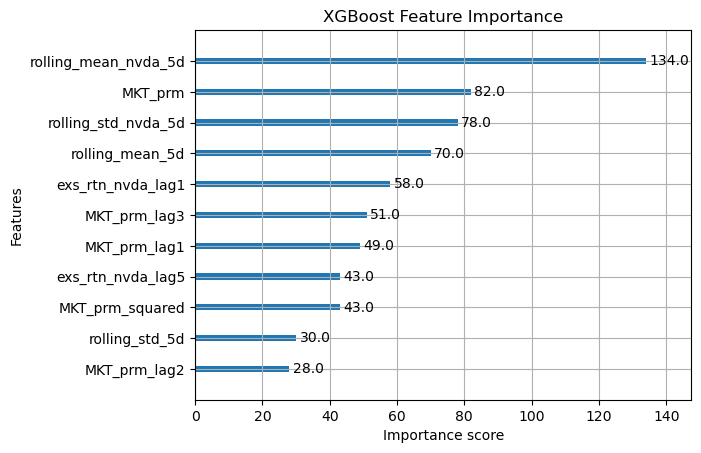

In [100]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(best_xgb)
plt.title("XGBoost Feature Importance")
plt.show()


## Random Forest


In [103]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [109]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Prepare your data
X = Stock_close_capm[['MKT_prm']]
y = Stock_close_capm['exs_rtn_nvda']

# Step 2: Time-aware split
split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Step 3: Fit Random Forest model
rf = RandomForestRegressor(n_estimators=100000, random_state=42)
rf.fit(X_train, y_train)

# Step 4: Predict and evaluate
y_pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)
n, p = X_test.shape
adj_r2_rf = 1 - (1 - r2_rf) * (n - 1) / (n - p - 1)

# Step 5: Print results
print("📊 Random Forest (CAPM):")
print(f"MSE: {mse_rf}")
print(f"RMSE: {rmse_rf}")
print(f"R²: {r2_rf}")
print(f"Adjusted R²: {adj_r2_rf}")



KeyboardInterrupt

